<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Tarea Semanal Nº2
#### Casandra Sotelino

#### Introduccion:
En esta tarea semanal se simulará el proceso de digitalización de una señal ejecutado por un ADC de 2 volts de rango de Voltaje y B bits.

Se crea una señal senoidal  con un ruido analógico con potencia proporcional a la potencia del ruido de cuantización que ocurre al cuantizar la señal de entrada. Serán proporcionales de la siguiente forma: $Pa = k . Pq$ donde Pa es la potencia del ruido analógico y $Pq = \frac{q ^2}{12}$ la del ruido de cuantización y $q = \frac{2 . Vref}{2 ^B}$ el ruido de cuantización.

A continuación se muestran los resultados de analizar las señales con sus respectivos ruidos (in-analógico, out-analógico+digital), sus espectros de frecuencia y su distribución (ruido de cuantización) para distintos valores de _k_ y de _B_.

In [27]:
#%% Librerías
import numpy as np
import matplotlib.pyplot as plt
#%% definiciones

fs = 1000 #frecuencia de sampleo
N = 1000 #número de muestras
N_B = int(3) #cantidad de bits a muestrear
N_k = int(3) #cantidad de k's a muestrear
B = [4, 8, 16];  #canidad de bits
k = [0.1, 1, 10];
Vref = 1 #rango del ADC = 2 -> toma valores de -1 a +1


#%%funciones

def function_sen_nq(A = np.sqrt(2), dc_sen = 0, ff = 1, ph = 0, nn = 1000,
                    fs = 1000, des_est = 1, dc_noise = 0):
    tt = np.arange(0, nn/fs, 1/fs)
    xx = A * np.sin(2 * np.pi * tt * ff + ph) + dc_sen #como A es = 1 entoces la energía se encuentra normalizada
    nq = np.random.normal(0, des_est, nn) + dc_noise
    f_suma = xx + nq
    return(tt, f_suma, xx)
#%%Script

def calculos_TS2(B, k):
    q = (2 * Vref) /(2 ** B) #niveles de cuantización
    Pq = q**2 / 12 #Potencia del ruido de cuantización
    Pa = k * Pq #Potencia del ruido analítico
    tt, sR, s = function_sen_nq(ff = 1, des_est = np.sqrt(Pa), ph= 0)
    
    sR_D = np.round(sR / q) * q #señal seno con ruido digitalizada
    
    FFT_senD = np.fft.fft(sR_D) / N
    FFT_senA = np.fft.fft(sR) / N
    
    FAdB = 20 * np.log10(np.abs(FFT_senA))
    FDdb = 20 * np.log10(np.abs(FFT_senD) + 1e-200) #agrego 1e-200 porque este argumento toma el valor 0, por lo que da error
    
    E_q = np.median(np.abs(FFT_senD)) #Media del espectro de potencia del sR_D
    E_q = 20 * np.log10(E_q)
    E_a = np.median(np.abs(FFT_senA)) #Media del espectro de potencia del sR
    E_a = 20 * np.log10(E_a)
     
    e_q = sR_D - sR #error de cuantizacion del ruido
    return(tt, s, sR, sR_D, FAdB, FDdb, E_a, E_q, e_q, q)


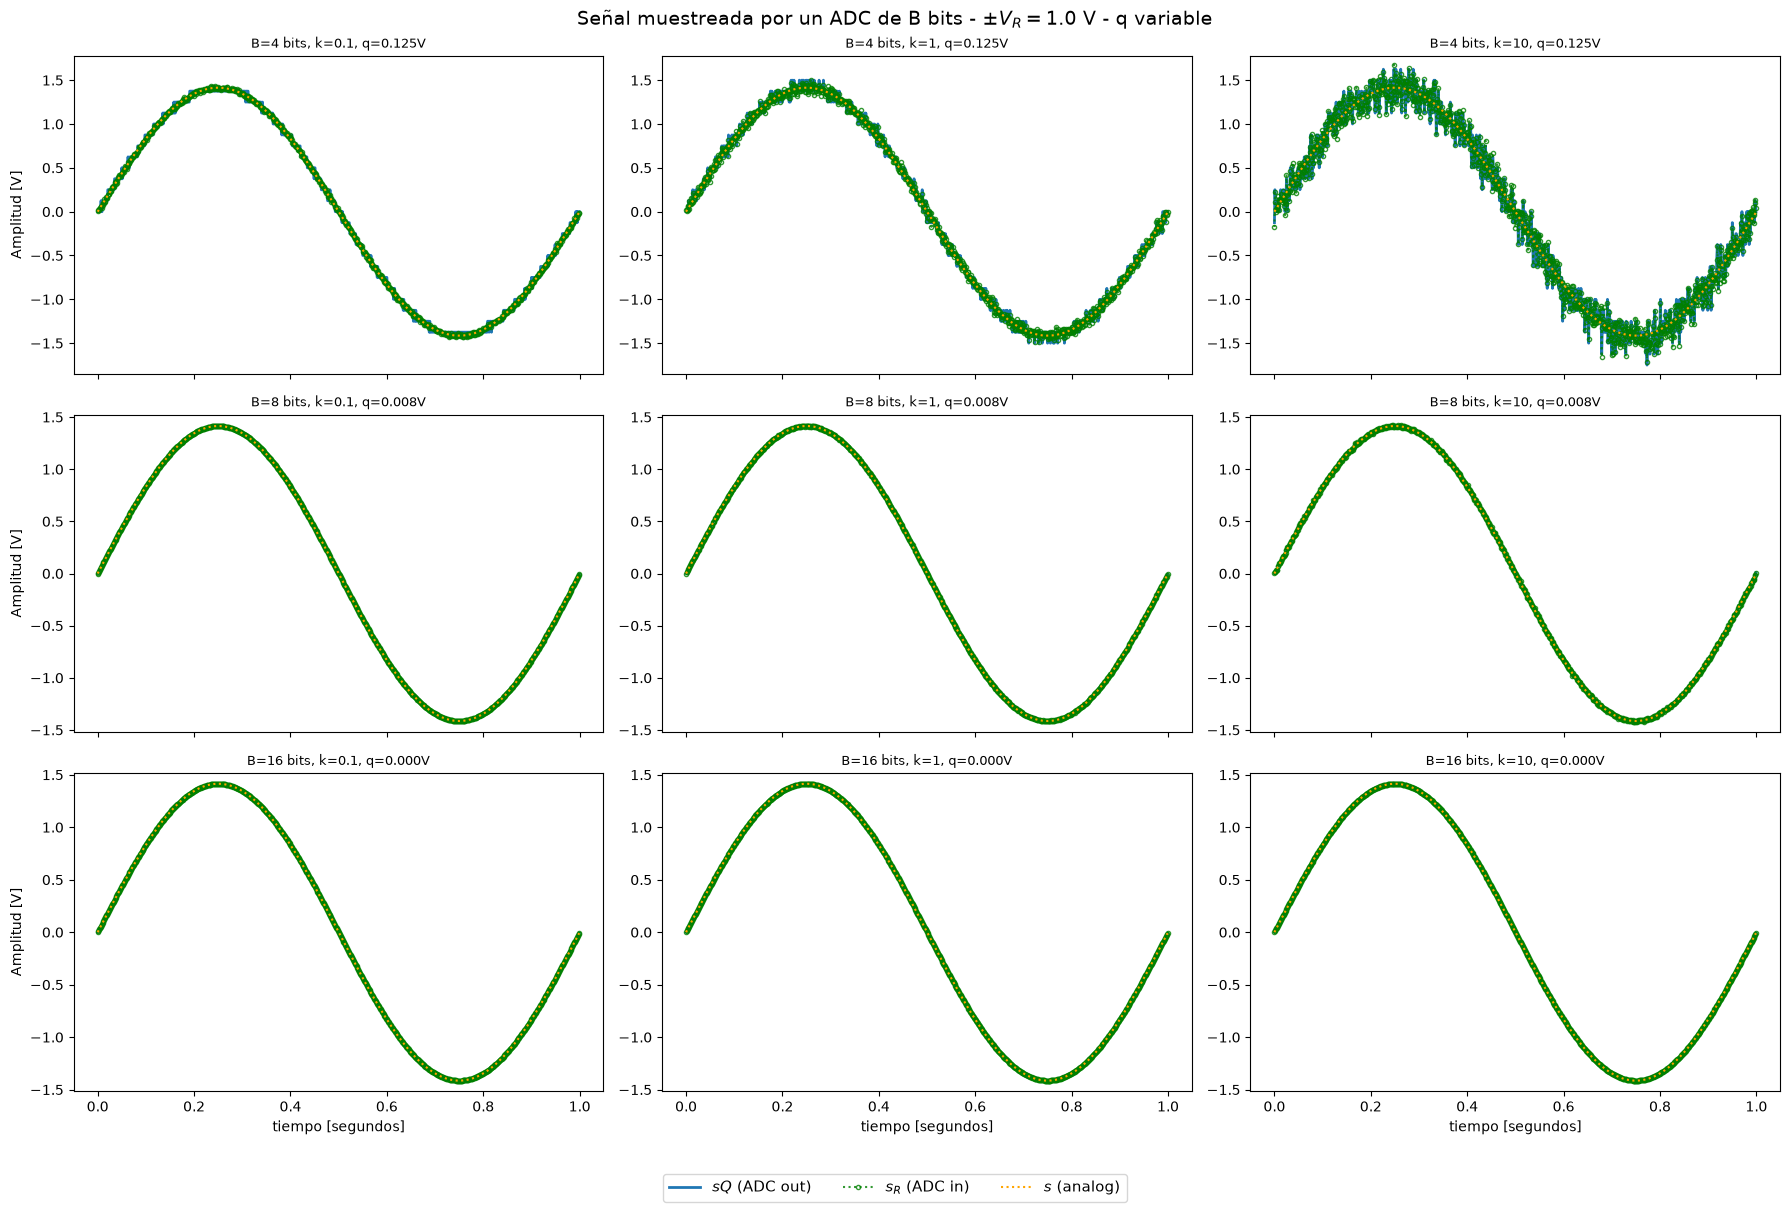

In [25]:
#%% Figura 2: senos(tt) - 3x3
fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
for i, Bi in enumerate(B):
    fila_datos = [calculos_TS2(Bi, kj) for kj in k]
    ymin = min(min(d[1].min() - 0.1, d[2].min() - 0.1, d[3].min() - 0.1) for d in fila_datos)
    ymax = max(max(d[1].max() + 0.1, d[2].max() + 0.1, d[3].max() + 0.1) for d in fila_datos)
    for j, kj in enumerate(k):
        tt, s, sR, sR_D, FAdB, FDdb, E_a, E_q, e_q, q = fila_datos[j]
        ax = axs[i, j]
        ax.plot(tt, sR_D, label=r"$sQ$ (ADC out)", color="#1f77b4", linewidth=2)
        ax.plot(tt, sR, label=r"$s_R$ (ADC in)", color="green", linestyle=":",
                marker="o", markersize=3, markerfacecolor="none",
                markeredgecolor="green", alpha=0.8)
        ax.plot(tt, s, label=r"$s$ (analog)", color="orange", linestyle=":", linewidth=1.5)
        ax.set_ylim(ymin, ymax)
        ax.set_title(f"B={Bi} bits, k={kj}, q={q:.3f}V", fontsize=9)
        if i == 2:
            ax.set_xlabel("tiempo [segundos]")
        if j == 0:
            ax.set_ylabel("Amplitud [V]")
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(rf"Señal muestreada por un ADC de B bits - $\pm V_R = {Vref:.1f}$ V - q variable", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 1])

_Figura 1. Señal muestreada por un ADC de B bits y k constante de proporcionalidad entre potencias_

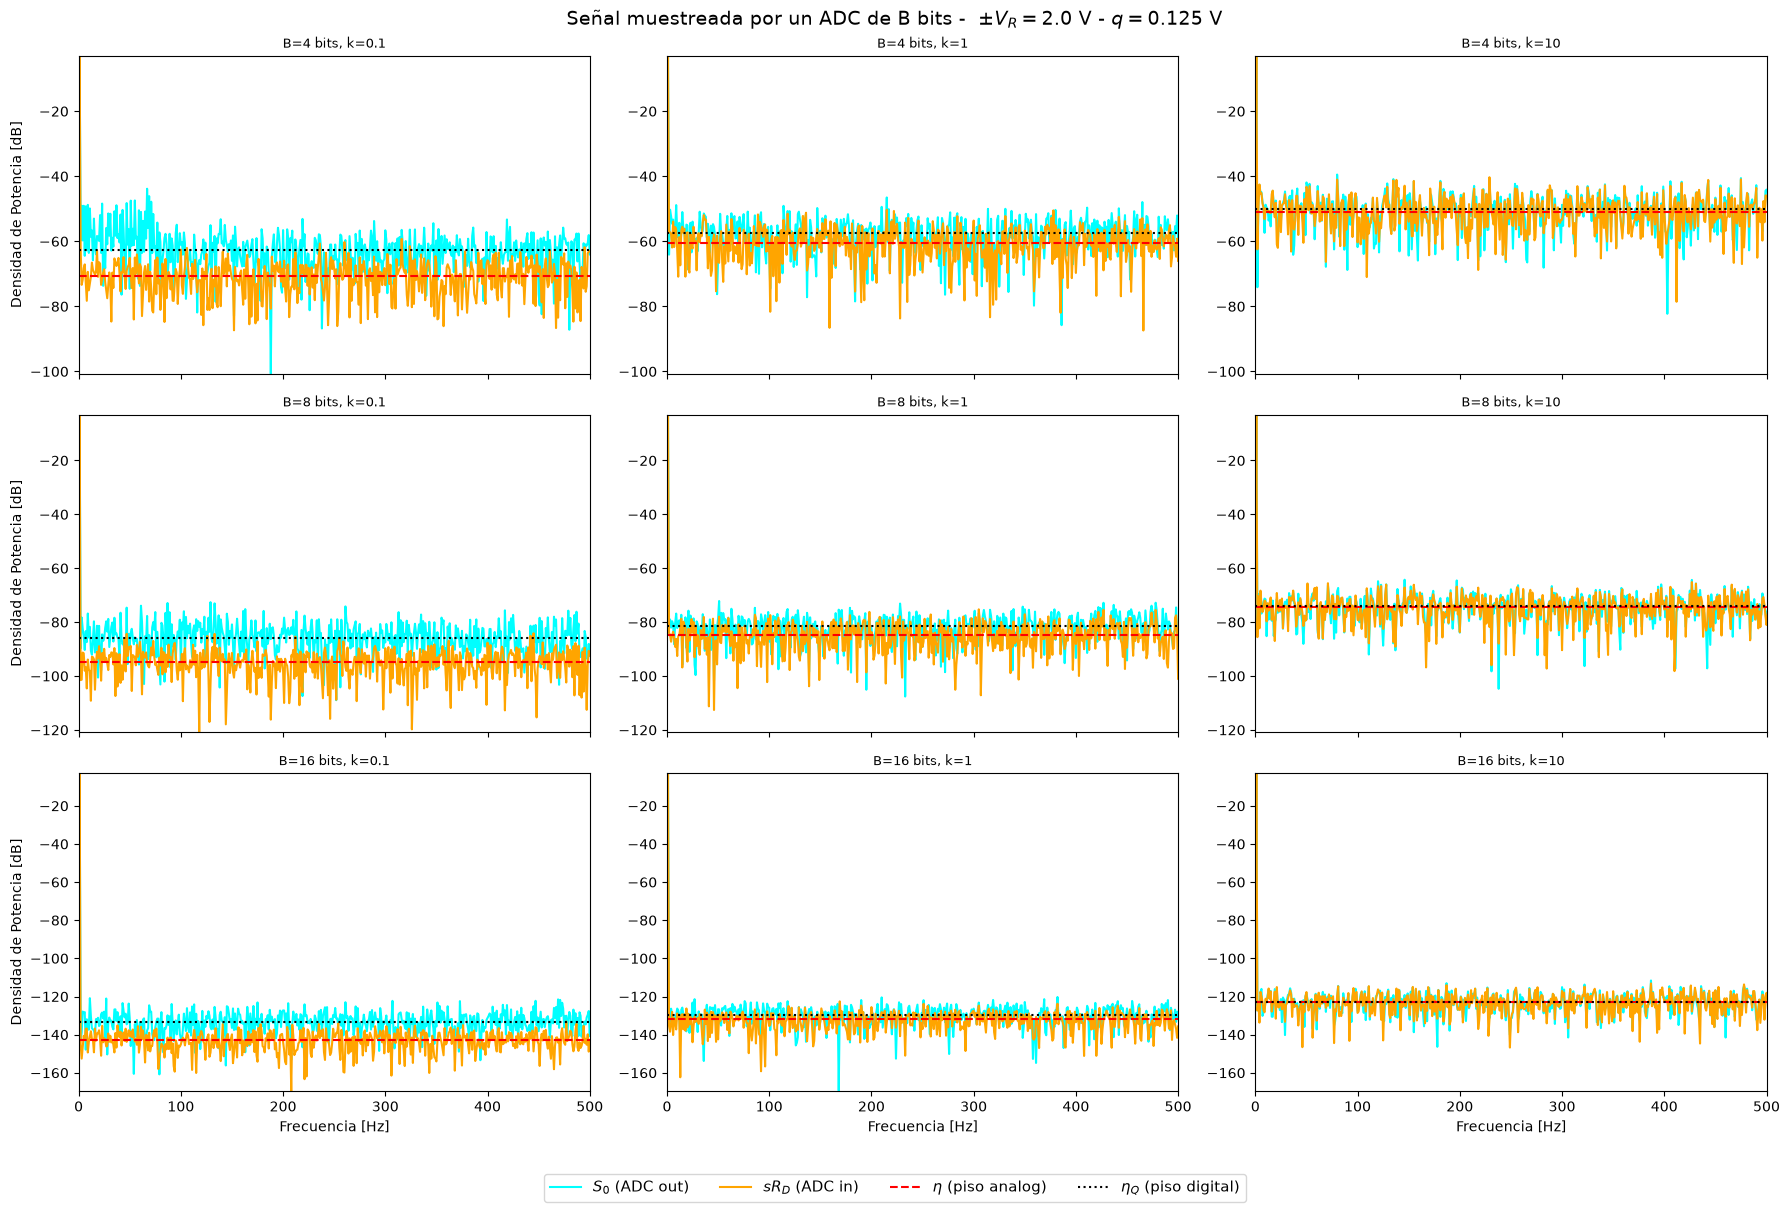

In [17]:
#%% Figura 1: Potencia (dB ruidos) - 3x3
fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharex=True)
for i, Bi in enumerate(B):
    fila_datos = [calculos_TS2(Bi, kj) for kj in k]
    ymin = min(min(d[4].min(), d[5].min()) for d in fila_datos)
    ymax = max(max(d[4].max(), d[5].max()) for d in fila_datos)
    for j, kj in enumerate(k):
        tt, s, sR, sR_D, FAdB, FDdb, E_a, E_q, e_q, q = fila_datos[j]
        ax = axs[i, j]
        ax.plot(FDdb, color="cyan", label=r'$S_0$ (ADC out)')
        ax.plot(FAdB, color="orange", label=r'$sR_D$ (ADC in)')
        ax.axhline(E_a, linestyle='--', color="red", label=r'$\eta$ (piso analog)')
        ax.axhline(E_q, linestyle=':', color="black", label=r'$\eta_Q$ (piso digital)')
        ax.set_xlim(0, 500)
        ax.set_ylim(ymin, ymax)
        ax.set_title(f"B={Bi} bits, k={kj}", fontsize=9)
        if i == 2:
            ax.set_xlabel('Frecuencia [Hz]')
        if j == 0:
            ax.set_ylabel('Densidad de Potencia [dB]')
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=11, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(r"Señal muestreada por un ADC de B bits -  $\pm V_R = 2.0$ V - $q = 0.125$ V", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 1])

_Figura (2) Densidad de potencia de la señal muestreada por un ADC de B bits con constante de proporcionalidad de potencias  k_

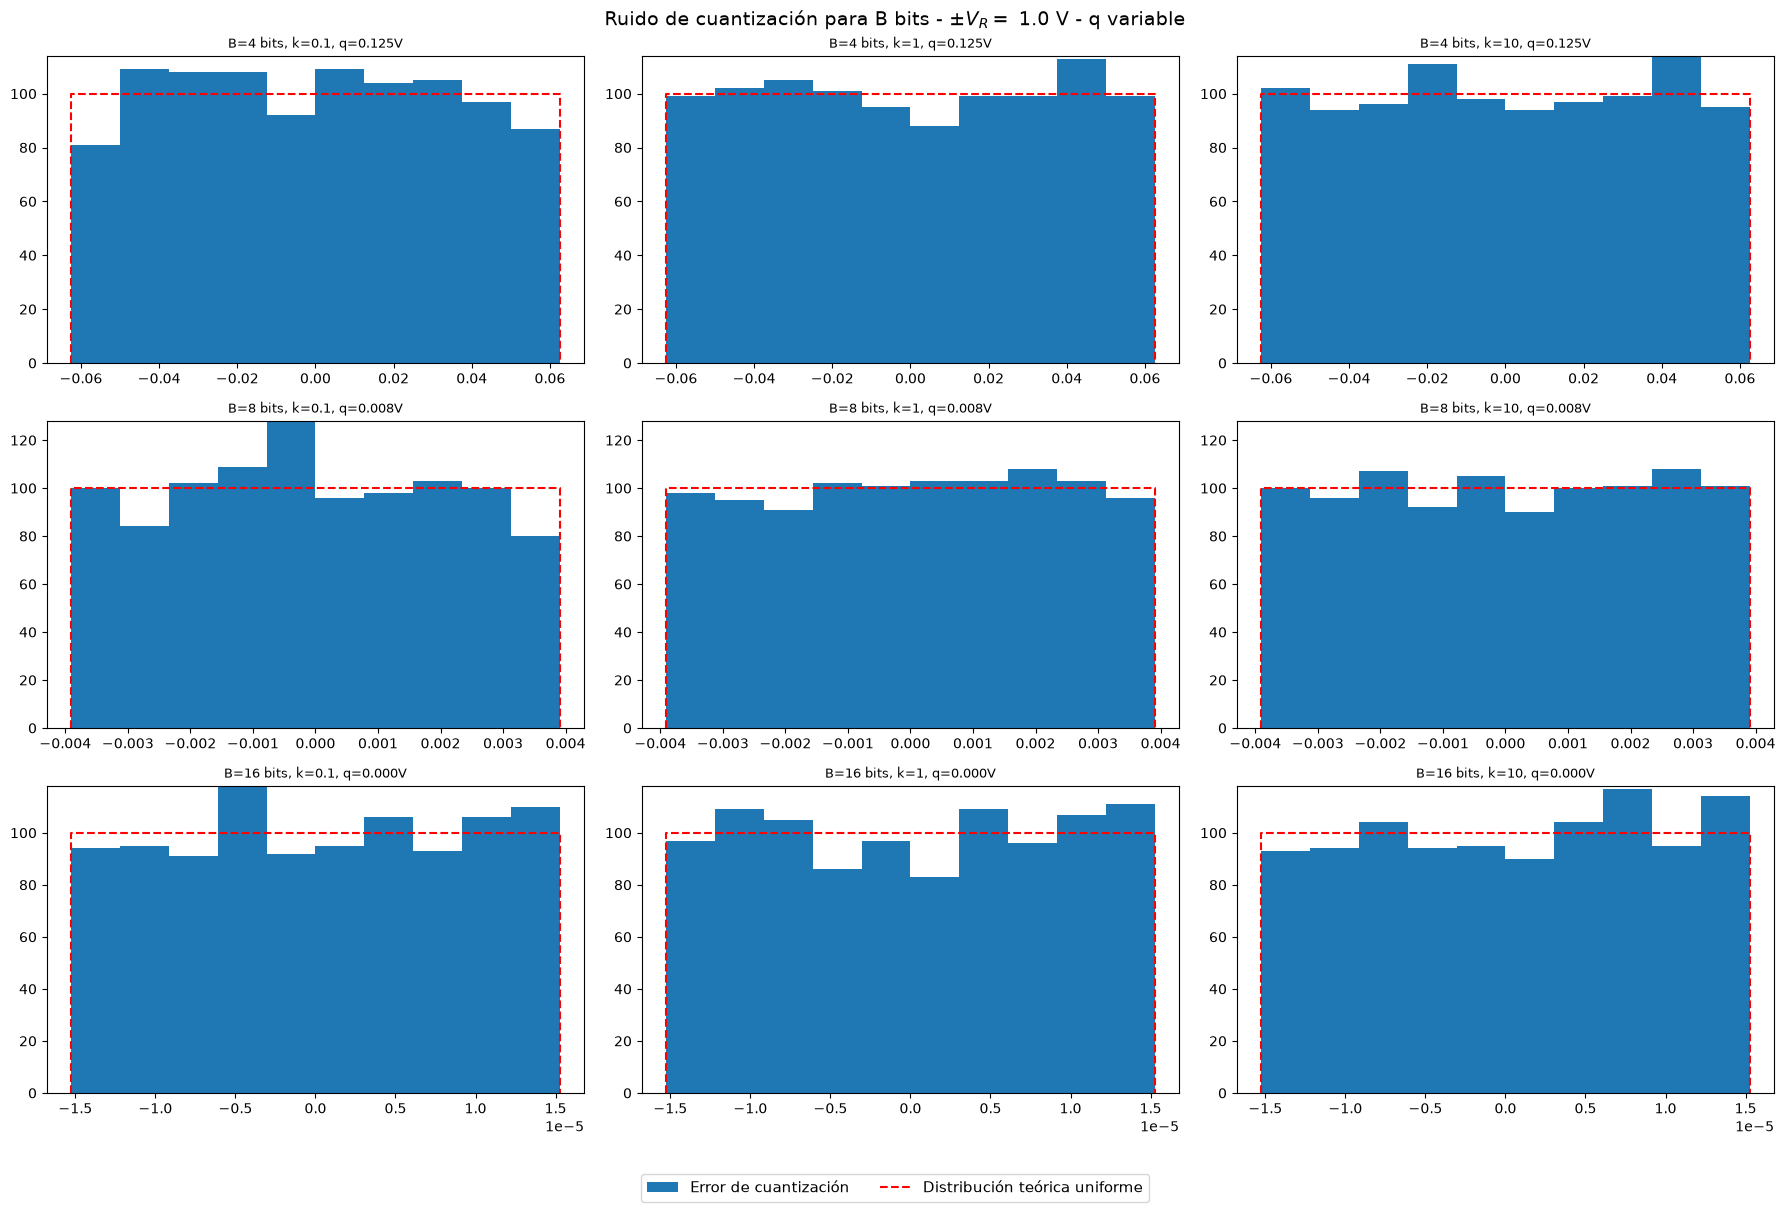

In [29]:
#%% Figura 3: Histograma - 3x3
fig, axs = plt.subplots(3, 3, figsize=(18, 12))
for i, Bi in enumerate(B):
    fila_datos = [calculos_TS2(Bi, kj) for kj in k]
    ymax = max(np.histogram(d[8], bins=10, range=(-d[9]/2, d[9]/2))[0].max() for d in fila_datos)
    for j, kj in enumerate(k):
        tt, s, sR, sR_D, FAdB, FDdb, E_a, E_q, e_q, q = fila_datos[j]
        ax = axs[i, j]
        ax.hist(e_q, bins=10, range=(-q/2, q/2), edgecolor="none", label="Error de cuantización")
        ax.plot([-q/2, -q/2, q/2, q/2], [0, 100, 100, 0],
                color="red", linestyle="--", linewidth=1.5, label="Distribución teórica uniforme")
        ax.set_ylim(0, ymax)
        ax.set_title(f"B={Bi} bits, k={kj}, q={q:.3f}V", fontsize=9)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(rf"Ruido de cuantización para B bits - $\pm V_R =$ {Vref:.1f} V - q variable", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

_Figura 3. Ruido de cuantización para B bits y k constante de proporcionalidad_

#### Análisis y discusión:

_Relación entre valores de potencias de ruidos y Bits en cuanto a las señales de ingreso y egreso del ADC_

Cuanto menor es el nivel de cuantización (q) se obtiene una resolución en la señal de egreso mayor. Por lo que las señales in_out se asemejarán de manera proporcional con la inversa de q.\
Por lo tanto, al observar la _Figura 1_ es posible inferir que para una buena resolución, la potencia del ruido de cuantización puede representar valores menores (en relacion con la potencia del ruido analógico) cuanto mayor es el número de Bits. Esto ocurre porque los niveles de cuantización son menores y Pq depende de ellos.

_Relación entre las potencias de los ruidos_

Se observa en la _Figura 2_ que la potencia media de la señal de entrada no tomará valores mayores a la de la señal de salida, esto ocurre porque la señal de egreso del ADC tiene ambos ruidos.\
Por otra parte ambos valores tienden a ser iguales cuando la potencia del ruido de cuantización es menor por si misma o en relacion a la analógica (mayor B o mayor k respectivamente). \
En definitiva, la búsqueda una igualdad entre ambas potencias nos otorgará una calidad adecuada sin necisidad de invertir en un ADC de alta calidad, ya que para una k muy cercana a 0, la señal adquirirá una gran cantidad de ruido al ser cuantizada, por lo que la resolución analógica sera altamente mayor a la cuantizada.\
Si el k es muy alto entonces el ADC es usualmente sobrecalificado para la señal analógica que recibe, entregandole un ruido de cuantización casi nulo.
Es por esto que una k = 1 se considera la óptima, ya que hará que la señal de egreso tenga una resolución adecuada, considerando que el ruido de la señal de entrada nunca será menor al de salida y el ruido de cuantización será aceptable.

_Análisis del ruido_

El ruido se demuestra incorrelado para ambos casos, debido a que sus potencias, como puede verse en la _Figura 2_, son una delta en frecuencia = 0 Hz.\
El ruido de cuantización tiene una distribución aparentemente uniforme ya que sus valores se distribuyen uniformemente entre -q/2 y q/2, respresentada en la _Figura 3_.